# Simulación campo magnético

Se simulan las líneas de campo alrededor de una espira con corriente estática $I$ y con forma circular.
Se usa un método numérico para calcular la contribución de la espira en un punto dado. Se modela todo con
la ecuación de Biot-Savart, la cual es denotada por:


\begin{equation*}
\text{d} \mathbf{B} = \frac{\mu_0 I}{4 \pi} \frac{\text{d} \mathbf{l} \times \hat{\mathbf{r}} }{r^2}
\end{equation*}

Se construye a partir de la ecuación el modelo diferencial que se va a usar para calcular el campo
en todos los puntos de un plano.

Esto mismo puede hacerse a depender de la posición relativa del punto a la espira, denotado como:

$$
\text{d} \mathbf{B} = \frac{\mu_0 I}{4 \pi} \left( \text{d} \mathbf{s} \times \frac{ \mathbf{r}' }{|| \mathbf{r}' ||^3} \right)
$$

In [1]:
using Latexify

In [2]:
using Plots

In [3]:
using LinearAlgebra

In [36]:
using LaTeXStrings

> Esto no era necesario, solo es por si tengo que escribir muchas euaciones resultado y eso

In [4]:
x_mesh(start, stop, len) = range(start, stop, len)'.*ones(len)

y_mesh(start, stop, len) = range(start, stop, len).*ones(len)'

y_mesh (generic function with 1 method)

In [5]:
# Constante magnética

K = 1e-7;
I = 5.0; # A

# Radio de la espira

a = 50e-2; # m ???

# TAMAÑO DE TODO

sizeee = 30;

# plano coordenado:

x = x_mesh(-1,1,sizeee);
y = y_mesh(-1,1,sizeee);

El integrando principal es:

$$\oint\limits_{C} \left( \text{d} \mathbf{s} \times \frac{ \mathbf{r}'}{||\mathbf{r}'||^3} \right) $$


In [6]:
# Se declara el iterador:

θ = range(0,2*pi,500);
dθ = diff(θ)[end];

ds(i) = [-sin(θ[i]); 0; cos(θ[i]) ].*a*dθ

ρ(x,y,i) = [ x-a*cos(θ[i]); y; -a*sin(θ[i]) ].*(-1)

ρ (generic function with 1 method)

In [7]:
b_component(x,y,n) = K*I* [ cross( ds(i),ρ(x,y,i)/(norm(ρ(x,y,i))^3) )[n] for i in eachindex(θ) ] |>sum

b_component (generic function with 1 method)

In [8]:
b = [b_component(1,-1,i) for i in 1:3]

3-element Vector{Float64}:
 -1.9944912933238904e-7
  8.79082153295482e-8
  9.279091757406471e-24

In [9]:
superBX = reshape([ b_component( x[i,j], y[i,j],1 ) for j in 1:sizeee for i in 1:sizeee ], (sizeee,sizeee));

In [10]:
superBY = reshape([ b_component( x[i,j], y[i,j],2 ) for j in 1:sizeee for i in 1:sizeee ], (sizeee,sizeee));

In [11]:
superBZ = reshape([ b_component( x[i,j], y[i,j],3 ) for j in 1:sizeee for i in 1:sizeee ], (sizeee,sizeee));

In [12]:
Mag_B = reshape([ sqrt(superBX[i,j]^2 + superBY[i,j]^2) for j in 1:sizeee for i in 1:sizeee  ], (sizeee,sizeee));

In [13]:

pythonplot()

Plots.PythonPlotBackend()

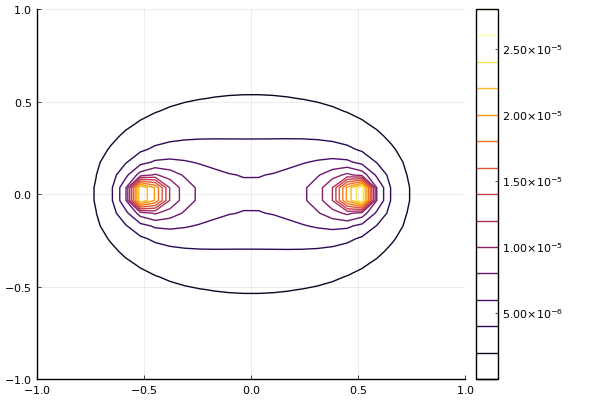

In [14]:
contour(x,y,Mag_B)

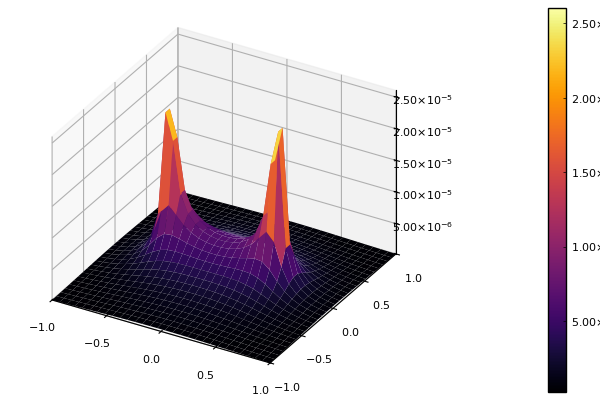

In [15]:
surface(x,y,Mag_B)

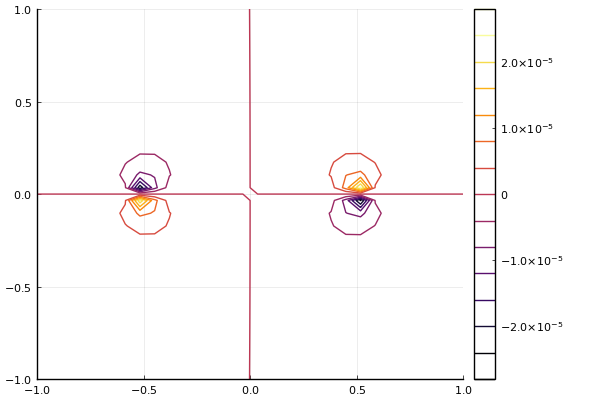

In [16]:
contour(x,y,superBX)

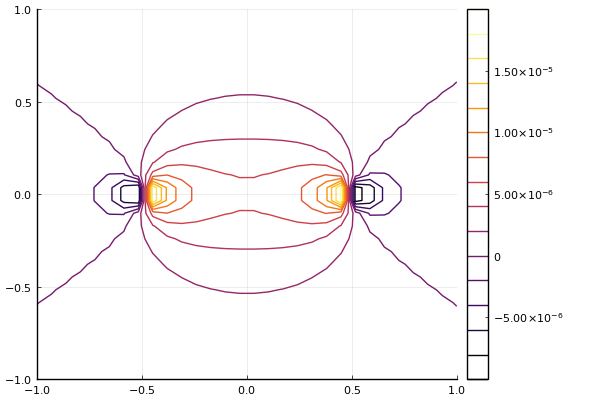

In [17]:
contour(x,y,superBY)

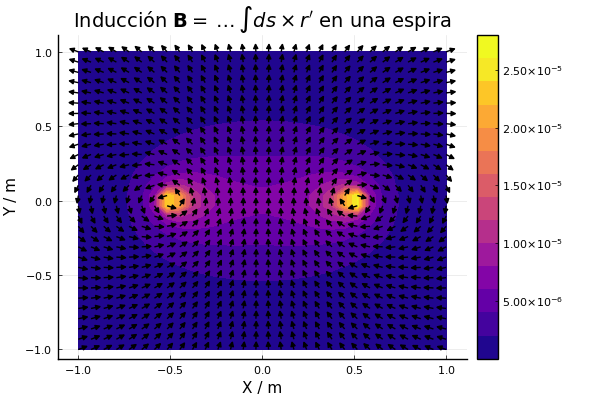

<sys>:0: UserWarning: The following kwargs were not used by contour: 'label'
<sys>:0: UserWarning: The following kwargs were not used by contour: 'label'
<sys>:0: UserWarning: The following kwargs were not used by contour: 'label'
<sys>:0: UserWarning: The following kwargs were not used by contour: 'label'


In [41]:
plot = contour(x,y, Mag_B, color=:plasma, clabels= false, fill = true)

quiver!(x,y, quiver=(superBX./Mag_B *5e-2, superBY./Mag_B * 5e-2 ), markersize=1, color=:black)

title!(L"Inducción $\mathbf{B} = \dots \int ds \times r'$ en una espira")
xlabel!("X / m")
ylabel!("Y / m")

In [42]:
savefig(plot, "campo.png")

<sys>:0: UserWarning: The following kwargs were not used by contour: 'label'


"/home/danielpi/Documents/project/simu-campo/campo.png"